In [ ]:
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#Check this site for the latest download link https://www.apache.org/dyn/closer.lua/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!wget -q https://archive.apache.org/dist/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys

import findspark
findspark.init()
findspark.find()

import pyspark

from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F


Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,626 B]
Hit:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:5 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:8 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,620 kB]
Hit:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:10 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 Packages [1,513 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/main amd64 Package

In [ ]:
spark = SparkSession.builder.appName("Mi primera").getOrCreate()

In [ ]:
!apt-get install git

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git is already the newest version (1:2.34.1-1ubuntu1.11).
0 upgraded, 0 newly installed, 0 to remove and 57 not upgraded.


In [ ]:
repository_url = "https://github.com/fruits-360/fruits-360-100x100"  # Replace with your repo URL
!git clone {repository_url}

Cloning into 'fruits-360-100x100'...
remote: Enumerating objects: 94555, done.
remote: Counting objects: 100% (3809/3809), done.
remote: Compressing objects: 100% (3799/3799), done.
remote: Total 94555 (delta 32), reused 3786 (delta 10), pack-reused 90746 (from 1)
Receiving objects: 100% (94555/94555), 723.85 MiB | 21.82 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Updating files: 100% (94112/94112), done.


In [ ]:
import os
from pyspark.sql import SparkSession

# Assuming images are in the 'images' directory within 'fruits-360-100x100'
repo_name = "fruits-360-100x100"  # Replace with your repository folder name

# Fix: Use the repository name directly as the path
# os.path.abspath() is not needed here and was causing the issue
repo_path = "/content/fruits-360-100x100"
repo_training_path = "/content/fruits-360-100x100/Training"
repo_test_path = "/content/fruits-360-100x100/Test"

# Change to the repository directory
os.chdir(repo_path) #Change the current working directory

# Get list of image training file paths
# Use 'in' instead of 'contains' to check if substring is present in filename


import random

# Define the folder names to include

def get_direct_subfolders(path):
    """
    Get a list of folder names directly inside the specified path.

    Args:
        path (str): Path to the directory.

    Returns:
        list: List of folder names.
    """
    try:
        subfolders = [folder for folder in os.listdir(path) if os.path.isdir(os.path.join(path, folder))]
        return subfolders
    except Exception as e:
        print(f"Error accessing the path {path}: {e}")
        return []

folder_names = get_direct_subfolders(repo_training_path)

# Dictionary to store selected files for each folder
selected_files_by_folder = {}



# Iterate over each folder
for folder_name in folder_names:
    # Collect all files in the current folder
    folder_files = [
        os.path.join(root, f)
        for root, dirs, files in os.walk(repo_training_path)
        if folder_name in root
        for f in files if f.endswith(('.png', '.jpg', '.jpeg'))
    ]
    # Randomly select up to 100 files from the folder
    selected_files_by_folder[folder_name] = random.sample(folder_files, min(10, len(folder_files)))

# Combine all selected files into one list if needed
image_training_files = [file for files in selected_files_by_folder.values() for file in files]



# Create an RDD from the list
image_rdd = spark.sparkContext.parallelize(image_training_files)

In [ ]:

image_rdd.count()

1410

In [ ]:
# @title
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from PIL import Image
from pyspark import SparkContext


# Define a transformation for preprocessing images
image_transform = transforms.Compose([
    transforms.Resize((100, 100)),  # Resize the image to 100x100 (based on the Fruits-360 dataset size)
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize((0.5,), (0.5,))  # Normalize image with mean and std
])

# Function to load and preprocess an image
def load_and_preprocess_image(image_path):
    try:
        img = Image.open(image_path).convert('RGB')  # Open and convert image to RGB
        img = image_transform(img)  # Apply transformations
        label = os.path.basename(os.path.dirname(image_path))  # Label is the folder name (class)
        return img, label
    except Exception as e:
        print(f"Error loading image {image_path}: {e}")
        return None

# Filter out any failed image loads
image_label_rdd = image_rdd.map(load_and_preprocess_image).filter(lambda x: x is not None)


In [ ]:
# @title

# Define a CNN model using PyTorch
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 25 * 25, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 25 * 25)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Define the training function
def train_model(model, dataloader, criterion, optimizer, num_epochs=5):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for inputs, labels in dataloader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {running_loss / len(dataloader)}")

# Creating a custom dataset class using PyTorch's Dataset module
class ImageDataset(torch.utils.data.Dataset):
    def __init__(self, image_label_list, transform=None):
        self.image_label_list = image_label_list
        self.transform = transform

    def __len__(self):
        return len(self.image_label_list)

    def __getitem__(self, idx):
        img, label = self.image_label_list[idx]
        if self.transform:
            img = self.transform(img)
        label = class_to_idx[label]  # Convert class name to index
        return img, label


In [ ]:
# @title
# Converting the RDD to a list (or you can split it into smaller partitions if memory is an issue)
image_label_list = image_label_rdd.collect()

In [ ]:
# @title
# Create a dictionary to map class names to indices
classes = sorted(set([label for _, label in image_label_list]))
class_to_idx = {cls: idx for idx, cls in enumerate(classes)}

# Create a PyTorch DataLoader for batching
batch_size = 32
dataset = ImageDataset(image_label_list)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Initialize the model, criterion, and optimizer
num_classes = len(classes)
model = CNNModel(num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Train the model
train_model(model, dataloader, criterion, optimizer, num_epochs=10)


Epoch [1/10], Loss: 4.815236812167697
Epoch [2/10], Loss: 2.8113156186209785
Epoch [3/10], Loss: 1.3141110261281332
Epoch [4/10], Loss: 0.6432735386821958
Epoch [5/10], Loss: 0.33886606825722587
Epoch [6/10], Loss: 0.2835315017236604
Epoch [7/10], Loss: 0.2106928016990423
Epoch [8/10], Loss: 0.2512407855441173
Epoch [9/10], Loss: 0.05106081642831365
Epoch [10/10], Loss: 0.11006506818036238


In [ ]:
# Save the model
torch.save(model.state_dict(), 'cnn_fruits360.pth')

In [ ]:
from pickle import TRUE
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image

# Define the CNN architecture (this must match the saved model architecture)
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 25 * 25, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 25 * 25)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize the model with the correct number of classes (based on your dataset)
num_classes = 141  # Adjust to the actual number of classes in your dataset
model = CNNModel(num_classes)

# Load the saved model weights
model.load_state_dict(torch.load('cnn_fruits360.pth', weights_only=True))

# Set the model to evaluation mode
model.eval()

# Define the same transformations used during training
image_transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Same normalization as used in training
])

# Function to preprocess and classify a single image
def classify_image(image_path, model):
    # Load the image
    image = Image.open(image_path).convert('RGB')

    # Apply the transformations
    image = image_transform(image).unsqueeze(0)  # Add batch dimension

    # Run inference
    with torch.no_grad():  # Disable gradient calculations for inference
        output = model(image)
        _, predicted = torch.max(output.data, 1)

    # Return the predicted class index
    return predicted.item()




In [ ]:
# Test the model on a sample image
test_image_path = "/content/fruits-360-100x100/Test/Orange 1/33_100.jpg"  # Provide the path to your test image
predicted_class = classify_image(test_image_path, model)

print(f"Predicted class: {classes[predicted_class]}")

Predicted class: Orange 1


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(image_test_files, model, class_to_idx):
    """
    Evaluates the model on a list of test images.

    Args:
        image_test_files (list): List of paths to test images.
        model (torch.nn.Module): The trained model.
        class_to_idx (dict): Mapping of class names to indices.

    Returns:
        None: Prints metrics and confusion matrix.
    """
    idx_to_class = {v: k for k, v in class_to_idx.items()}  # Reverse mapping: index to class name

    # Ground truth labels and predictions
    y_true = []
    y_pred = []

    for image_path in image_test_files:
        # Ground truth label (from folder name)
        true_label = os.path.basename(os.path.dirname(image_path))
        y_true.append(class_to_idx[true_label])

        # Predicted label using classify_image
        predicted_idx = classify_image(image_path, model)
        y_pred.append(predicted_idx)

    # Compute metrics
    acc = accuracy_score(y_true, y_pred)
    print(f"Accuracy: {acc * 100:.2f}%")

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print("\nConfusion Matrix:")
    print(cm)

    # Optionally, show the classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=[idx_to_class[i] for i in sorted(class_to_idx.values())]))

    # from sklearn.metrics import classification_report

    # Generate the classification report as a dictionary
    # report = classification_report(
    #     y_true, y_pred,
    #     target_names=[idx_to_class[i] for i in sorted(class_to_idx.values())],
    #     output_dict=True
    # )

    # Filter and print only classes with precision less than 1
    # print("\nFiltered Classification Report (Precision < 1):")
    # for class_name, metrics in report.items():
    #     # Ignore the 'accuracy' or other summary metrics in the report
    #     if isinstance(metrics, dict) and 'precision' in metrics:
    #         if metrics['precision'] < 1:
    #             print(f"Class: {class_name}")
    #             print(f"  Precision: {metrics['precision']:.2f}")
    #             print(f"  Recall: {metrics['recall']:.2f}")
    #             print(f"  F1-Score: {metrics['f1-score']:.2f}")


    # Plot confusion matrix without numbers
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=False, cmap='Blues')#, xticklabels=[idx_to_class[i] for i in sorted(class_to_idx.values())], yticklabels=[idx_to_class[i] for i in sorted(class_to_idx.values())])
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()



In [ ]:
# Get list of image test file paths
# Use 'in' instead of 'contains' to check if substring is present in filename

selected_files_by_folder_test = {} # Initialize the dictionary before using it

# Iterate over each folder
for folder_name in folder_names:
    # Collect all files in the current folder
    test_folder_files = [
        os.path.join(root, f)
        for root, dirs, files in os.walk(repo_test_path)
        if folder_name in root
        for f in files if f.endswith(('.png', '.jpg', '.jpeg'))
    ]
    # Randomly select up to 10 files from the folder
    selected_files_by_folder_test[folder_name] = random.sample(test_folder_files, max(10, len(test_folder_files)))

image_test_files = [file for files in selected_files_by_folder.values() for file in files]

In [ ]:
len(image_test_files)

1410

Accuracy: 99.93%

Confusion Matrix:
[[10  0  0 ...  0  0  0]
 [ 0 10  0 ...  0  0  0]
 [ 0  0 10 ...  0  0  0]
 ...
 [ 0  0  0 ... 10  0  0]
 [ 0  0  0 ...  0 10  0]
 [ 0  0  0 ...  0  0 10]]

Classification Report:
                       precision    recall  f1-score   support

              Apple 6       1.00      1.00      1.00        10
     Apple Braeburn 1       1.00      1.00      1.00        10
 Apple Crimson Snow 1       1.00      1.00      1.00        10
       Apple Golden 1       1.00      1.00      1.00        10
       Apple Golden 2       1.00      1.00      1.00        10
       Apple Golden 3       1.00      1.00      1.00        10
 Apple Granny Smith 1       1.00      1.00      1.00        10
    Apple Pink Lady 1       1.00      1.00      1.00        10
          Apple Red 1       1.00      1.00      1.00        10
          Apple Red 2       1.00      1.00      1.00        10
          Apple Red 3       1.00      1.00      1.00        10
Apple Red Delicious 1      

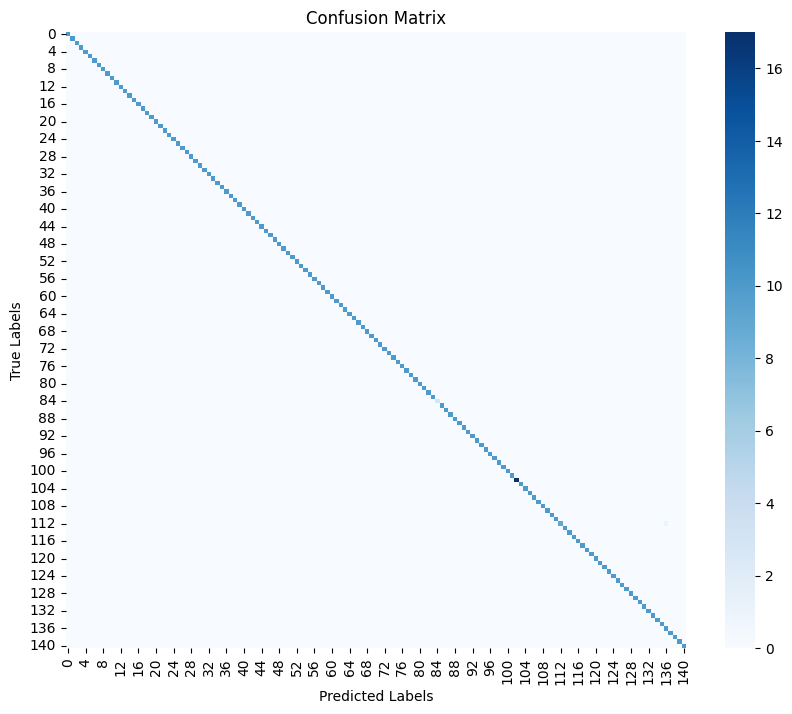

In [ ]:
# Assuming `image_test_files` is a list of test image paths
# and `class_to_idx` is the class-to-index mapping created earlier

evaluate_model(image_test_files, model, class_to_idx)
